
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [1]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [2]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [3]:

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence) # YOUR CODE HERE
pos_tags = nltk.pos_tag(tokens) # YOUR CODE HERE

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
DT means determiner and it is used to detect the position of nouns. JJ means adjectives that describe the noun.
2. Why do you think 'brown' and 'lazy' have the same tag? Because they're both adjectives that add detail to the nouns, fox and dog.
3. Can you guess what 'VBZ' represents? It represents a verb.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [4]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence) # YOUR CODE HERE

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's? SpaCy's tags is easier.
- Do you notice any differences in how they tag the same words? I see that SpaCy and NTLK have different labels for tagging the same words. For example, SpaCy tags words that are adjectives as ADJ but NTLK will say that they are JJ instead.
- Which system would you prefer for a beginner? Why?
I prefer SpaCy because it is more user-friendly, easy to understand and interpret, and it is slightly more accurate than the NLTK.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [5]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
    # My ambiguous sentences
    "This fly is so annoying.",          # fly = noun (insect)
    "Some people can be scared to fly because of the airplane's turbelence."            # fly = verb (soaring through the air)
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank','fly']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN

Sentence: This fly is so annoying.
  🎯 'fly' is tagged as: NN

Sentence: Some people can be scared to fly because of the airplane's turbelence.
  🎯 'fly' is tagged as: VB



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?

It looks at the previous word and word after the token to see what type of position the token is in.

2. What clues in the sentence help determine the correct part of speech?

Context and the words surrounding the token

3. Can you think of other words that change meaning based on context?

Fly (insect) and Fly (soaring through the air)

Hard (level of diffuculty) and Hard (stiff)

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [6]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (w, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

The Penn Treebank is more detailed while the universal is simpler.

2. When might you want detailed tags vs. simple tags? Enter your answer

Simple Tags:
Search Engines

Detailed Tags:
Document Analyzer

3. If you were building a search engine, which would you choose? Why? Enter your answer below

I would use universal because the tags are simpler and since that is the case, it will take less computational power.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [7]:
# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # TODO: SpaCy processing
    spacy_doc = nlp(text)

    # TODO: Find problematic words (tagged as 'X' or unknown)
    # For NLTK, 'X' typically means unknown/unrecognized. We'll also consider common informal words that might get generic tags.
    # For SpaCy, 'X' (Other) and 'SYM' (Symbol) are good indicators of problematic tokens.
    problematic_nltk = [word for word, tag in nltk_tags if tag == 'X' or tag == 'FW']
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X' or token.pos_ == 'SYM']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    nltk_success_rate = (len(nltk_tokens) - len(problematic_nltk)) / len(nltk_tokens) if len(nltk_tokens) > 0 else 0
    spacy_success_rate = (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc) if len(spacy_doc) > 0 else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy suc


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?

Neither

2. What types of words cause the most problems?

Acronyms and abbreviations

3. How might you preprocess text to improve tagging accuracy?

Remove punctuation and interpret acronyms

4. What are the implications for real-world applications?

High Inaccuracy



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [8]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# Define keyword lists for analysis (previously undefined, causing NameError)
emotional_adjective_keywords = ['frustrated', 'unacceptable', 'small', 'ridiculous', 'confused']
problem_noun_keywords = ['account', 'files', 'issue', 'app', 'billing', 'system', 'features', 'interface']
positive_sentiment_keywords = ['love', 'good', 'happy', 'great', 'excellent', 'helpful']
negative_sentiment_keywords = ['frustrated', 'locked', 'crashes', 'unacceptable', 'ridiculous', 'terrible', 'bad']
urgent_keywords = ['immediately', 'asap', 'urgent', 'now']


# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicatores (nouns related to issues)

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # Process with SpaCy
    doc = nlp(call['transcript'])

    # Extract different types of words
    extracted_emotional_adjectives = [token.text for token in doc if token.pos_ == 'ADJ' and token.text.lower() in emotional_adjective_keywords]
    extracted_action_verbs = [token.text for token in doc if token.pos_ == 'VERB']
    extracted_problem_nouns = [token.text for token in doc if token.pos_ == 'NOUN' and token.text.lower() in problem_noun_keywords]

    # Calculate sentiment indicators
    positive_words = [token.text for token in doc if token.text.lower() in positive_sentiment_keywords]
    negative_words = [token.text for token in doc if token.text.lower() in negative_sentiment_keywords]

    # Count urgent words
    urgency_indicators_count = len([token.text for token in doc if token.text.lower() in urgent_keywords])

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': extracted_emotional_adjectives,
        'action_verbs': extracted_action_verbs,
        'problem_nouns': extracted_problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_indicators_count
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {extracted_emotional_adjectives}")
    print(f"Action verbs: {extracted_action_verbs}")
    print(f"Problem nouns: {extracted_problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency indicators: {result['urgency_indicators']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: ['account', 'files']
Sentiment score: -3
Urgency indicators: 0

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small']
Action verbs: ['love', 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue', 'app']
Sentiment score: 0
Urgency indicators: 0

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this

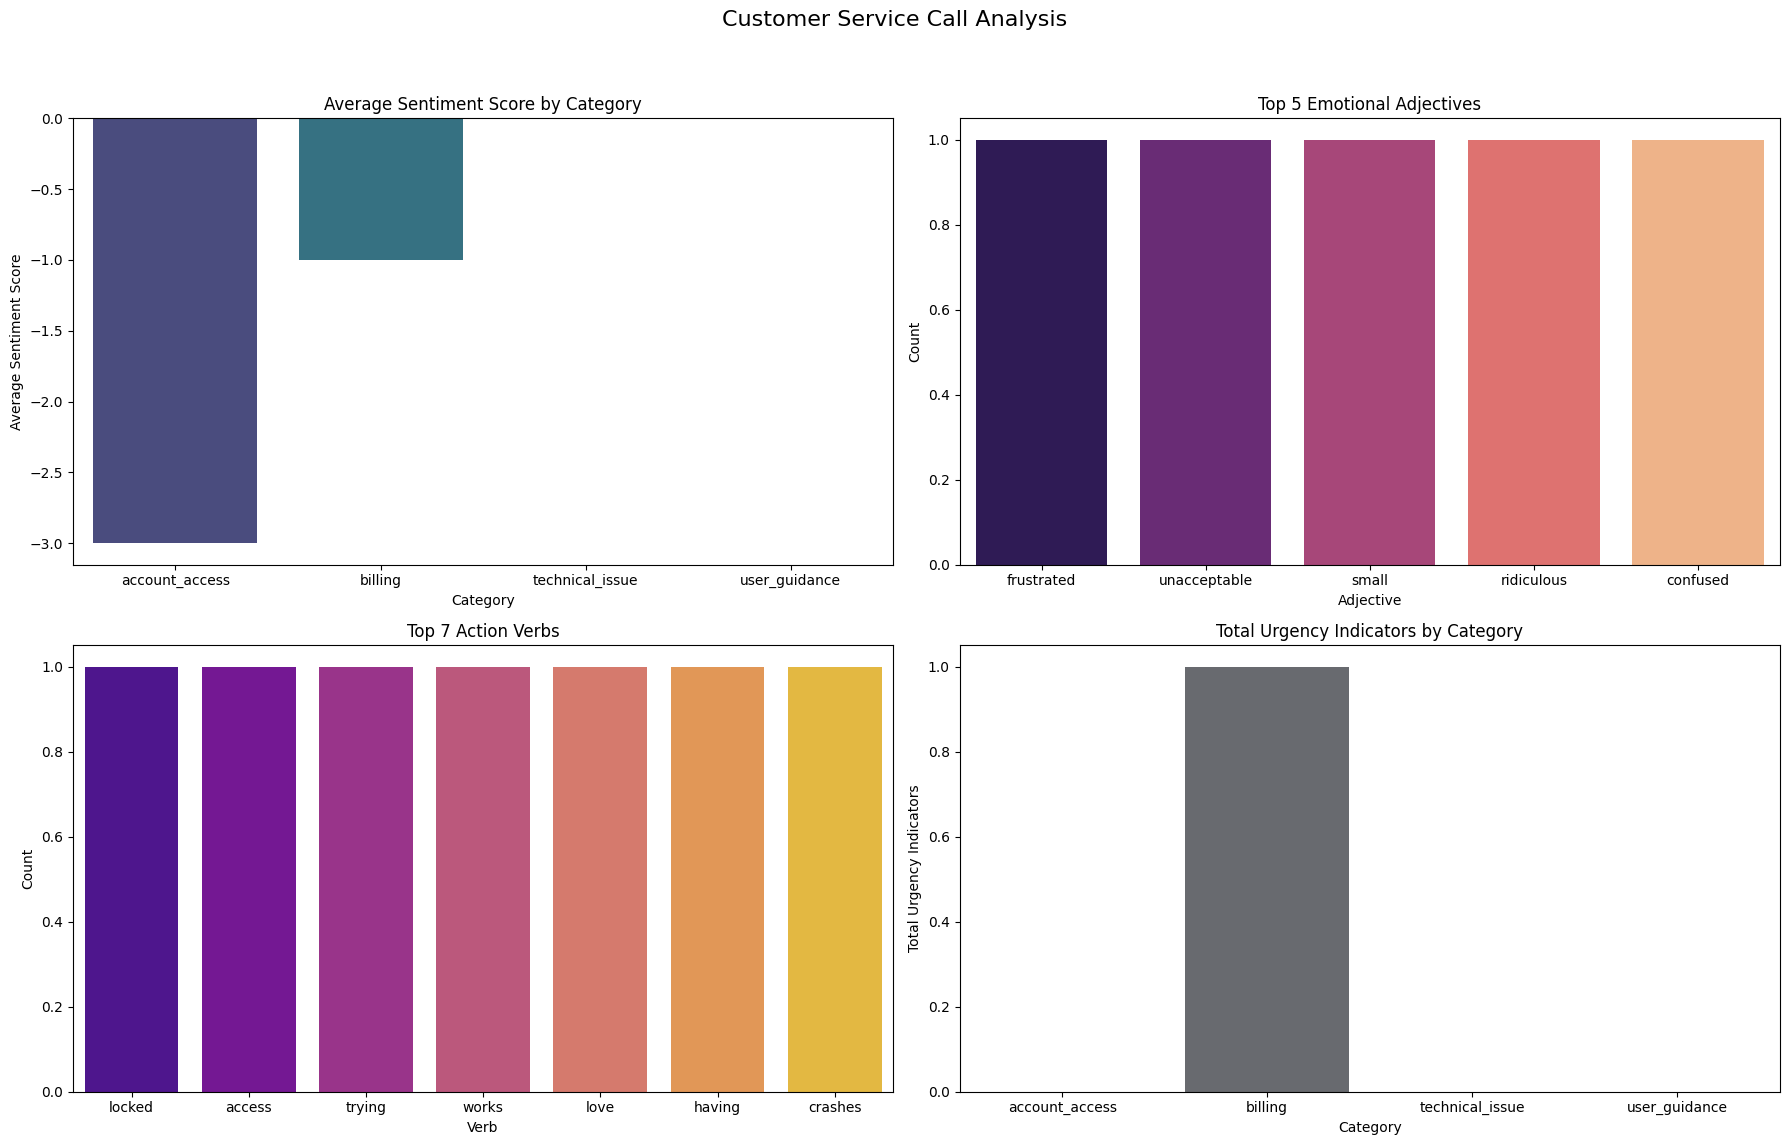

In [9]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import seaborn as sns

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency
# 4. Urgency analysis

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Customer Service Call Analysis', fontsize=16)

# Plot 1 - Sentiment by category
sentiment_by_category = df.groupby('category')['sentiment_score'].mean().reset_index()
sns.barplot(x='category', y='sentiment_score', data=sentiment_by_category, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Average Sentiment Score by Category')
axes[0, 0].set_ylabel('Average Sentiment Score')
axes[0, 0].set_xlabel('Category')

# Plot 2 - Most common emotional adjectives
all_emotional_adjectives = [adj for sublist in df['emotional_adjectives'] for adj in sublist]
adj_counts = Counter(all_emotional_adjectives)
top_adjectives_df = pd.DataFrame(adj_counts.most_common(5), columns=['Adjective', 'Count'])
sns.barplot(x='Adjective', y='Count', data=top_adjectives_df, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Top 5 Emotional Adjectives')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Adjective')

# Plot 3 - Action verbs frequency
all_action_verbs = [verb for sublist in df['action_verbs'] for verb in sublist]
verb_counts = Counter(all_action_verbs)
top_verbs_df = pd.DataFrame(verb_counts.most_common(7), columns=['Verb', 'Count'])
sns.barplot(x='Verb', y='Count', data=top_verbs_df, ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title('Top 7 Action Verbs')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Verb')

# Plot 4 - Urgency analysis by category
urgency_by_category = df.groupby('category')['urgency_indicators'].sum().reset_index()
sns.barplot(x='category', y='urgency_indicators', data=urgency_by_category, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Total Urgency Indicators by Category')
axes[1, 1].set_ylabel('Total Urgency Indicators')
axes[1, 1].set_xlabel('Category')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?

We can see what is the cause of the negative reviews and make improvements.

2. What patterns do you notice in different problem categories?

The words that it flags as a problem are words that have more than one meanings and depending on the meaning it can be tagged differently.

3. How might you automate the routing of calls based on POS analysis?

I would route the calls based on POS analysis by their sentiment score. The lower the sentiment score the more urgent it is.

4. What are the limitations of this approach?

Even though the sentiment score not might be the lowest, it doesn't mean it is not urgent. In the categories, there was a sentiment score that was 1, the lowest sentiment score was -2. Even though it was not the lowest, there were still words that indicated that it was urgent.



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7a4a21a3f8b0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

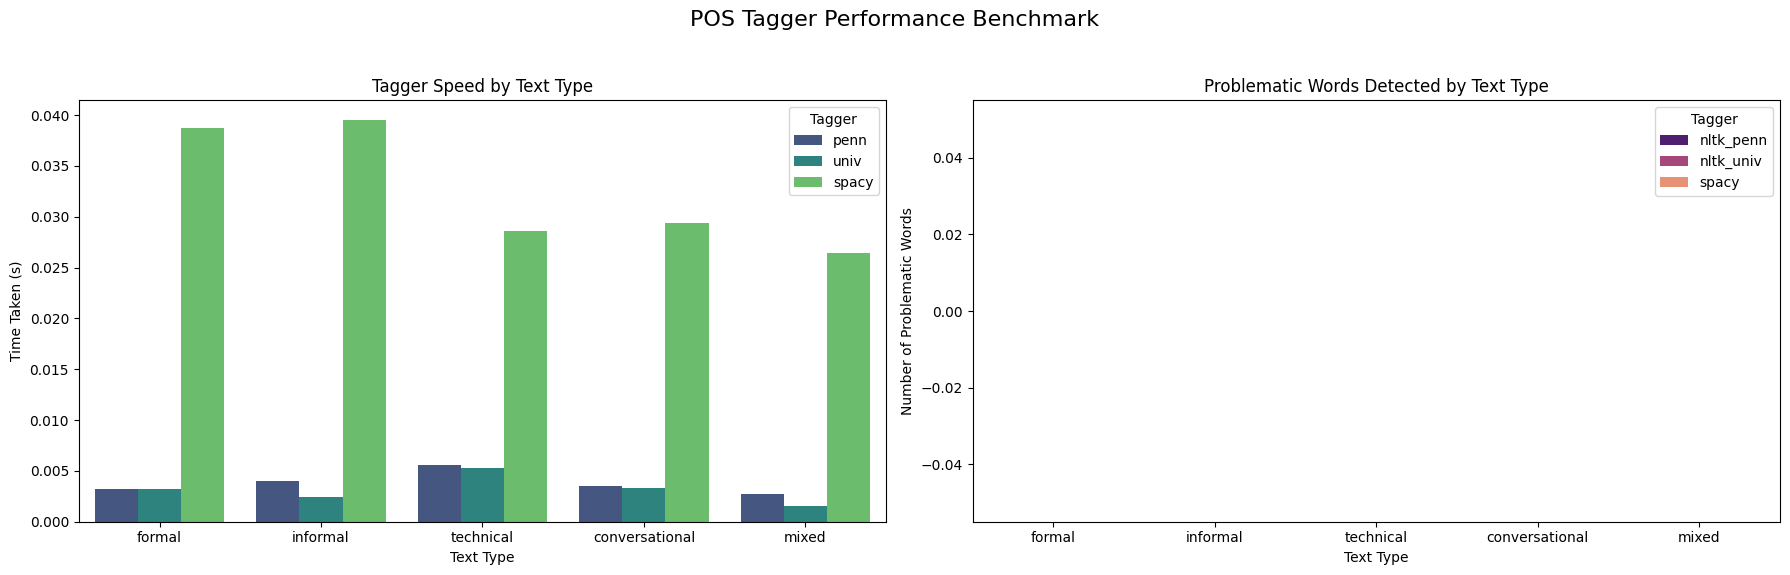

In [10]:
import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n\ud83e\uddea Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing and unknown words
    start_time = time.time()
    nltk_tokens_penn = nltk.word_tokenize(text)
    nltk_tags_penn = nltk.pos_tag(nltk_tokens_penn)
    nltk_penn_time = time.time() - start_time
    nltk_unknown_penn = len([word for word, tag in nltk_tags_penn if tag == 'X' or tag == 'FW'])

    # NLTK Universal timing and unknown words
    start_time = time.time()
    nltk_tokens_univ = nltk.word_tokenize(text)
    nltk_tags_univ = nltk.pos_tag(nltk_tokens_univ, tagset='universal')
    nltk_univ_time = time.time() - start_time
    nltk_unknown_univ = len([word for word, tag in nltk_tags_univ if tag == 'X'])

    # SpaCy timing and unknown words
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time
    spacy_unknown = len([token.text for token in spacy_doc if token.pos_ == 'X' or token.pos_ == 'SYM'])

    # Store results
    benchmark_results['text_type'].append(text_type)
    benchmark_results['nltk_penn_time'].append(nltk_penn_time)
    benchmark_results['nltk_univ_time'].append(nltk_univ_time)
    benchmark_results['spacy_time'].append(spacy_time)
    benchmark_results['nltk_unknown_penn'].append(nltk_unknown_penn)
    benchmark_results['nltk_unknown_univ'].append(nltk_unknown_univ)
    benchmark_results['spacy_unknown'].append(spacy_unknown)

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK Penn unknown words: {nltk_unknown_penn}")
    print(f"NLTK Universal unknown words: {nltk_unknown_univ}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# Create performance comparison visualization
df_bench = pd.DataFrame(benchmark_results)

# Melt the DataFrame for easier plotting of times
df_time = df_bench.melt(id_vars=['text_type'], value_vars=['nltk_penn_time', 'nltk_univ_time', 'spacy_time'],
                        var_name='tagger', value_name='time_taken')
df_time['tagger'] = df_time['tagger'].str.replace('_time', '').str.replace('nltk_', '')

# Melt the DataFrame for easier plotting of unknown words
df_unknown = df_bench.melt(id_vars=['text_type'], value_vars=['nltk_unknown_penn', 'nltk_unknown_univ', 'spacy_unknown'],
                           var_name='tagger', value_name='unknown_words')
df_unknown['tagger'] = df_unknown['tagger'].str.replace('nltk_unknown_penn', 'nltk_penn').str.replace('nltk_unknown_univ', 'nltk_univ').str.replace('spacy_unknown', 'spacy')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('POS Tagger Performance Benchmark', fontsize=16)

# Plotting Time Taken
sns.barplot(x='text_type', y='time_taken', hue='tagger', data=df_time, ax=axes[0], palette='viridis')
axes[0].set_title('Tagger Speed by Text Type')
axes[0].set_ylabel('Time Taken (s)')
axes[0].set_xlabel('Text Type')
axes[0].legend(title='Tagger')

# Plotting Unknown Words
sns.barplot(x='text_type', y='unknown_words', hue='tagger', data=df_unknown, ax=axes[1], palette='magma')
axes[1].set_title('Problematic Words Detected by Text Type')
axes[1].set_ylabel('Number of Problematic Words')
axes[1].set_xlabel('Text Type')
axes[1].legend(title='Tagger')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?

The formal tagger was the fastest. I don't think speed matters for my use case.

2. Which handles informal text best?

SpaCy

3. How do the taggers compare on technical jargon?

The penn and universal type are very close in speed when handling text types except for the informal text type.

4. What trade-offs do you see between speed and accuracy?

For some reason, I can't see how accurate the taggers because the graph, Problematic Words Detected by Text Type, is blank.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [13]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tags =  nltk.pos_tag(nltk.word_tokenize(text)) # YOUR CODE HERE
        spacy_doc = nlp(text) # YOUR CODE HERE

        # TODO: Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        #--TODO: Analyze what went wrong--#
        # YOUR ANALYSIS CODE HERE
        print("\n--- Analysis ---")
        nltk_problematic_tags = [w for w, t in nltk_tags if t in ['X', 'FW']]
        spacy_problematic_tags = [t.text for t in spacy_doc if t.pos_ in ['X', 'SYM']]

        if nltk_problematic_tags:
            print(f"  NLTK flagged problematic (X/FW) words: {nltk_problematic_tags}")
        if spacy_problematic_tags:
            print(f"  SpaCy flagged problematic (X/SYM) words: {spacy_problematic_tags}")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
# YOUR REFLECTION CODE HERE
print("1. Ambiguity: Words like 'buffalo', 'flies', 'can', and 'police' clearly demonstrate how context is crucial. Taggers struggle when a word can function as a noun, verb, or adjective without strong syntactic cues, often leading to differing interpretations between NLTK and SpaCy.")
print("2. Specialized Vocabulary: Modern technical terms ('COVID-19', 'AI/ML', 'microservices') and social media elements ('@username', '#hashtag', emojis) often lack clear grammatical categories in traditional tag sets or are out-of-vocabulary for trained models. Taggers might default to 'PROPN' (SpaCy), 'NN' (NLTK), or 'SYM'/'X' (both) as a best guess, indicating a failure to correctly categorize.")
print("3. Recursive/Garden Path Sentences: Sentences like 'Buffalo buffalo...' or 'The man the boat the river.' are grammatically valid but semantically challenging. While individual words might be tagged correctly in isolation, the overall sentence structure and meaning are complex, pushing the limits of purely statistical or rule-based POS tagging without deeper syntactic parsing.")
print("4. Tokenization Differences: Especially with non-standard text (e.g., URLs, emojis, complex acronyms), NLTK's `word_tokenize` and SpaCy's tokenizer often segment text differently. This impacts subsequent tagging accuracy and makes direct word-for-word tag comparisons challenging.")
print("5. Generalization to New Domains: While modern taggers are robust, they are trained on specific corpuses. Text types significantly different from their training data (e.g., highly informal chat, domain-specific jargon, historical texts) can lead to reduced accuracy and more 'unknown' or generic tags, indicating a lack of understanding of the domain's specific linguistic patterns.\n\nSolutions often involve custom training on domain-specific data, specialized dictionaries, rule-based systems for specific patterns, or leveraging more advanced neural network models that can better capture context and semantics.")



🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]

--- Analysis ---

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET'), ('arrow', 'NOUN'), (';', 'PUNCT'), ('fruit', 'NOUN'), ('flies', 'NOUN'),


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

Taggers struggle with words that can function as than one position tag without strong signals that it might be the case.

2. How might you preprocess text to handle some of these issues?

I would train the text preprocessing libraries to analyze when there's a word repeating itself back to back and see if it is grammatically correct. Most of the time it is not.

3. When would these limitations matter in real applications?

AI that is built to handle grammatical errors like Grammerly
Sentiment Analysis on customer reviews of a product or service

4. How do modern large language models handle these cases differently?

It would probably be more accurate preprocess text by removing stop words and punctuation before pos tagging.

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
Based on my experience I would choose SpaCy because the pos tags are easier to understand. I don't think the average user would know what JJ stands for compared to ADJ. SpaCy is also much faster and accurate. I could probably use to make a search engine or chatbot. I don't about a search engine, but I see myself making a chatbot in the future maybe for a website or to help me reduce the amount of emails I have to respond to.

**2. Real-World Applications:**

Business Problem: A car company's revenue is decreasing because their new released car is not getting many sales.

Solution: Use POS tagging to help summarize what the review is saying and conduct sentiment analysis. After that, we use the information gained from the sentiment analysis to have the AI reccomend better solutions.

**3. Limitations and Solutions:**

Limitations:
- Knowing the meaning of the word in certain context
- Recognizing text lingo or informal speech like fr, ASAP, u, rn, ngl, lol, and more

Solutions:
- POS tag the word and that will help the module know what it means
- Turning the text lingo into what it means because text lingo is abbreviations of words or a word

**4. Future Learning:**
I would like to explore domain adaption and post-preprocessing.

**5. Integration:**
NLP tasks that might benefit from POS tagging are tokenization and stemming or lemmitization.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
